In [3]:
from sklearn.preprocessing import Normalizer

feature_order = [
    # 'epoch', 'train_size',

    # old
    # 'loss_start', 'loss_mid',
    'loss_last_1', 'loss_last_2',
    # 'loss_growth', 'loss_stability',

    # gap
    # 'gap_last', 'gap_growth', 'gap_std',

    # global
    # 'best_loss',
    'epochs_since_best',
    'global_slope', 'global_curvature',
    # 'distance_from_best',

    # recent
    'recent_slope', 'recent_improvement',

    'acc_norm', 'distance_norm'
]

In [4]:
import pandas as pd
import numpy as np
import ast

from keras.src.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/final.csv", sep=';')

# строки -> списки
df['val_loss'] = df['val_loss'].map(ast.literal_eval)
df['train_loss'] = df['train_loss'].map(ast.literal_eval)

# flatten если вложенные списки
df['val_loss'] = df['val_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])
df['train_loss'] = df['train_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])

# фильтр
df = df[df['val_loss'].apply(lambda x: len(x) > 4)]
df = df[df['shift_type'].isin(['none', 'noise'])]
# -------- LOSS FEATURES --------

df["loss_start"] = df["val_loss"].apply(lambda x: x[0])
df["loss_mid"] = df["val_loss"].apply(lambda x: x[len(x) // 2])
df["loss_last_1"] = df["val_loss"].apply(lambda x: x[-2] / x[0])
df["loss_last_2"] = df["val_loss"].apply(lambda x: x[-3] / x[0])
df['acc_norm'] = df["val_loss"].apply(
    lambda c: ((c[-2] - c[-3]) - (c[-3] - c[-4])) / (c[-3] + 1e-8)
)
df["epoch"] = df["val_loss"].apply(len)
df["loss_end"] = df["val_loss"].apply(lambda x: x[-1])
df["loss_growth"] = df["loss_end"] - df["loss_start"]
df["loss_stability"] = df["val_loss"].apply(lambda x: np.std(x[:-1]))

df['distance_norm'] = df['val_loss'].apply(lambda x: (x[-2] - min(x[:-1])) / (x[0] - min(x[:-1]) + 1e-8))


# -------- GLOBAL CONTEXT FEATURES --------

def build_global_features(val_loss):
    val = np.array(val_loss)
    n = len(val)

    x = np.arange(n)

    # --- глобальный тренд ---
    slope = np.polyfit(x, val, 1)[0] if n > 1 else 0

    # --- кривизна (ускорение тренда) ---
    curvature = np.polyfit(x, val, 2)[0] if n > 2 else 0

    # --- лучший момент ---
    best_idx = np.argmin(val)
    best_loss = val[best_idx]

    # --- текущая позиция ---
    current_loss = val[-1]

    return pd.Series({
        "global_slope": slope,
        "global_curvature": curvature,

        "best_loss": best_loss,
        "distance_from_best": current_loss - best_loss,
        "epochs_since_best": n - best_idx,
    })


global_df = df["val_loss"].apply(build_global_features)
df = pd.concat([df, global_df], axis=1)


# -------- LOCAL (RECENT) FEATURES --------

def build_recent_features(val_loss, window=5):
    val = np.array(val_loss)
    n = len(val)

    if n < 2:
        return pd.Series({
            "recent_slope": 0,
            "recent_improvement": 0
        })

    val_recent = val[-window:] if n >= window else val
    x = np.arange(len(val_recent))

    slope = np.polyfit(x, val_recent, 1)[0] if len(val_recent) > 1 else 0

    improvement = val_recent[0] - val_recent[-1]

    return pd.Series({
        "recent_slope": slope,
        "recent_improvement": improvement
    })


recent_df = df["val_loss"].apply(build_recent_features)
df = pd.concat([df, recent_df], axis=1)

# -------- CLEAN --------
train_delta = (df["loss_end"] - df["loss_last_1"]) / df["loss_last_1"]
threshold = 0.5 * np.std(train_delta)
df['imbalance'] = df['imbalance'].astype(int)

# df = df.drop(columns=[
#     "val_loss",
#     "train_loss",
#     "val_acc",
#     "index",
#     "seed"
# ])

# -------- FEATURES --------

X = df[feature_order]
y = df["val_loss"].apply(lambda x: (x[-1] - x[-2]) / (x[-2] + 1e-8))
# y = y / np.std(y)
print(df.describe())
print(y.describe())
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

             index        epoch     test_acc  overfitting   train_size  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000   
mean   2098.242424    34.793290     0.753080     0.500000  1264.285714   
std    1202.835262    23.561086     0.156870     0.500068  1652.649140   
min       0.000000     6.000000     0.097500     0.000000    50.000000   
25%     993.250000    21.000000     0.639775     0.000000   100.000000   
50%    2211.500000    28.000000     0.769250     0.500000   500.000000   
75%    3135.250000    40.000000     0.889625     1.000000  2000.000000   
max    4059.000000   210.000000     0.982500     1.000000  5000.000000   

              seed    imbalance   loss_start     loss_mid  loss_last_1  ...  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000  ...   
mean      6.106061     0.500000     1.600830     0.721397     0.430032  ...   
std       3.810903     0.500068     0.706650     0.507957     0.176769  ...   
min       0.00000

In [5]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# model = RandomForestRegressor(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1
# )
model = XGBRegressor()

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.019165702207436738
RMSE: 0.041345589388898596
R2: 0.30769462946235426


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

normalizer = layers.Normalization()
normalizer.adapt(X_train.to_numpy())
# --- модель ---
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # количество признаков
    normalizer,
    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(32, activation='relu'),

    layers.Dense(1),
])

# --- компиляция ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

# --- обучение ---
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

# --- предсказание ---
pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Epoch 1/100


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.4373 - mae: 0.9294 - val_loss: 0.1168 - val_mae: 0.2625
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6877 - mae: 0.6549 - val_loss: 0.1348 - val_mae: 0.2896
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4528 - mae: 0.5152 - val_loss: 0.1033 - val_mae: 0.2314
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3898 - mae: 0.4744 - val_loss: 0.0949 - val_mae: 0.1952
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3280 - mae: 0.4323 - val_loss: 0.0910 - val_mae: 0.1897
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3188 - mae: 0.4184 - val_loss: 0.0899 - val_mae: 0.1881
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2683 - mae: 0.3861 - val_loss: 0.0951 - val_mae: 0.1910
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2446 - mae: 0.3666 - val_loss: 0.0921 - val_mae: 0.1909
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2203 - mae: 0.3

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np


def benchmark_regressors(models, X_train, X_test, y_train, y_test):
    results = []

    for name, model in models.items():
        # обучение
        model.fit(X_train, y_train)

        # предсказание
        pred = model.predict(X_test)

        # метрики
        r2 = r2_score(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))

        results.append({
            "model": name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse,
            "mm": model
        })

    results_df = pd.DataFrame(results)
    return results_df.sort_values("R2", ascending=False)

In [8]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)

models = {

    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),

    "DecisionTree": DecisionTreeRegressor(),

    "RandomForest": RandomForestRegressor(n_estimators=200),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200),

    "GradientBoosting": GradientBoostingRegressor(),
    "HistGradientBoosting": HistGradientBoostingRegressor(),

    "AdaBoost": AdaBoostRegressor(),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "SVR": SVR(),

    "MLP": MLPRegressor(max_iter=500)
}

results = benchmark_regressors(
    models,
    X_train,
    X_test,
    y_train,
    y_test
)

print(results)

                   model            R2       MAE       RMSE  \
3           RandomForest      0.540365  0.017089   0.033689   
4             ExtraTrees      0.515698  0.017234   0.034581   
6   HistGradientBoosting      0.514117  0.018173   0.034637   
5       GradientBoosting      0.491357  0.019157   0.035439   
0       LinearRegression      0.382776  0.020006   0.039039   
1                  Ridge      0.299096  0.022280   0.041602   
8                    KNN      0.234841  0.021686   0.043467   
2           DecisionTree      0.089198  0.025059   0.047423   
9                    SVR     -0.006370  0.025348   0.049849   
7               AdaBoost     -0.401286  0.049661   0.058823   
10                   MLP -74411.185429  0.904798  13.555089   

                                                   mm  
3   (DecisionTreeRegressor(max_features=1.0, rando...  
4   (ExtraTreeRegressor(random_state=1884591911), ...  
6                     HistGradientBoostingRegressor()  
5   ([DecisionTreeR

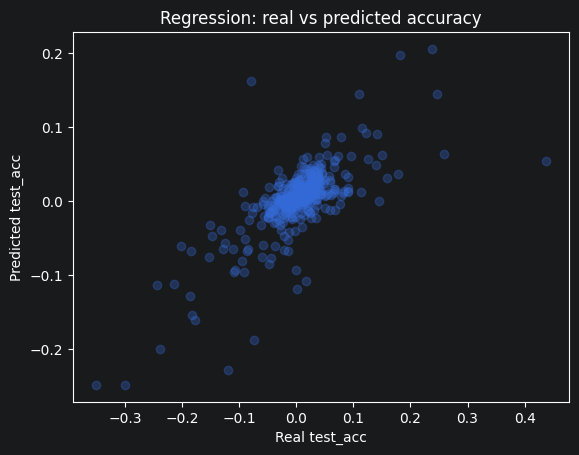

In [9]:
import matplotlib.pyplot as plt

pred = results.iloc[0]["mm"].predict(X_test)

plt.scatter(y_test, pred, alpha=0.3)

plt.xlabel("Real test_acc")
plt.ylabel("Predicted test_acc")
plt.title("Regression: real vs predicted accuracy")

# plt.plot([0,1],[0,1])
plt.show()


=== Результат предсказания следующего val_loss ===
MAE   = 0.01709
RMSE  = 0.03369
R²    = 0.5404   (54.04%)


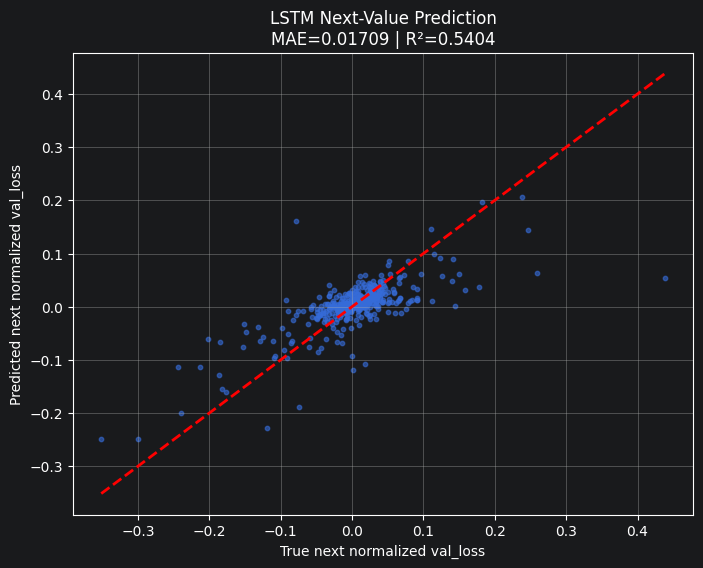

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ========================
# Создаём и обучаем модель
# ========================
# ========================
# Метрики
# ========================
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2  = r2_score(y_test, pred)

print("\n=== Результат предсказания следующего val_loss ===")
print(f"MAE   = {mae:.5f}")
print(f"RMSE  = {rmse:.5f}")
print(f"R²    = {r2:.4f}   ({r2*100:.2f}%)")

# ========================
# График True vs Predicted
# ========================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.6, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True next normalized val_loss")
plt.ylabel("Predicted next normalized val_loss")
plt.title(f"LSTM Next-Value Prediction\nMAE={mae:.5f} | R²={r2:.4f}")
plt.grid(True)
plt.show()

In [9]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback


class SmartEarlyStoppingMultiStep(Callback):
    def __init__(
        self,
        model_meta,
        train_size,
        future_steps=3,
        min_epochs=5,
        threshold_increase=1e-3,
    ):
        super().__init__()
        self.should_stop = False
        self.model_meta = model_meta
        self.train_size = train_size
        self.future_steps = future_steps
        self.min_epochs = min_epochs
        self.threshold_increase = threshold_increase

        self.train_loss = []
        self.val_loss = []
        self.counter = 0
        self.patience = 3


    def on_epoch_end(self, epoch, logs=None):
        train_loss = logs.get("loss")
        val_loss = logs.get("val_loss")

        if train_loss is None or val_loss is None:
            return

        self.train_loss.append(train_loss)
        self.val_loss.append(val_loss)

        if len(self.val_loss) < self.min_epochs:
            return

        preds = self.predict_future(epoch)

        trend = np.polyfit(range(len(preds)), preds, 1)[0]
 # или 2–5

        if trend > 0:
            self.counter += 1
        else:
            self.counter = 0

        if self.counter >= self.patience:

            print(f"Expected future increase → stopping at epoch {epoch}")
            self.model.stop_training = True
            self.should_stop = True

        print(
            f"epoch={epoch} val_loss={val_loss:.4f} "
            f"future={[round(x, 4) for x in preds]} trend={trend:.6f}"
        )

    # --- core ---
    def predict_future(self, epoch):
        val = list(self.val_loss)
        train = list(self.train_loss)

        preds = []

        for step in range(self.future_steps):

            val_np = np.array(val)
            train_np = np.array(train)
            min_len_np = len(val_np)
            # --- safety ---
            if min_len_np < 5:
                val_np = np.pad(val_np, (5 - min_len_np, 0), "edge")
                train_np = np.pad(train_np, (5 - min_len_np, 0), "edge")

            # gap = train_np - val_np

            # --- last values (safe) ---
            def safe_idx(arr, i):
                return arr[i] if len(arr) > abs(i) else arr[0]

            # --- global features ---
            x_full = np.arange(min_len_np)

            global_slope = np.polyfit(x_full, val_np, 1)[0] if min_len_np > 1 else 0
            global_curvature = np.polyfit(x_full, val_np, 2)[0] if min_len_np > 2 else 0

            best_idx = np.argmin(val_np)
            best_loss = val_np[best_idx]

            # --- recent ---
            window = 5
            val_recent = val_np[-window:] if min_len_np >= window else val_np
            x_recent = np.arange(len(val_recent))

            recent_slope = np.polyfit(x_recent, val_recent, 1)[0] if len(val_recent) > 1 else 0
            recent_improvement = val_recent[0] - val_recent[-1]

            row = {
                "train_size": self.train_size,
                "epoch": epoch + step,

                # --- base ---
                "loss_start": val_np[0],
                "loss_mid": val_np[min_len_np//2],
                "loss_last_1": safe_idx(val_np, -1) / val_np[0],
                "loss_last_2": safe_idx(val_np, -2) / val_np[0],
                "loss_last_3": safe_idx(val_np, -3) / val_np[0],

                "loss_acceleration": (safe_idx(val_np, -1) - 2 * safe_idx(val_np, -2) + safe_idx(val_np, -3)),
                "loss_growth": val_np[-1] - val_np[0],
                "loss_stability": np.std(val_np),

                # --- gap ---
                # "gap_last": gap[-1],
                # "gap_growth": gap[-1] - gap[0],
                # "gap_std": np.std(gap),

                # --- global ---
                "best_loss": best_loss,
                "epochs_since_best": min_len_np - best_idx,
                "global_slope": global_slope,
                "global_curvature": global_curvature,
                "distance_from_best": val_np[-1] - best_loss,
                "progress_ratio": min_len_np / 100.0,

                # --- recent ---
                "recent_slope": recent_slope,
                "recent_improvement": recent_improvement,
                "acc_norm": (safe_idx(val_np, -1) - 2 * safe_idx(val_np, -2) + safe_idx(val_np, -3)) / val_np[0],
                "distance_norm":  (safe_idx(val_np, -1) - min(val_np)) / (val_np[0] - min(val_np) + 1e-8),
            }

            df = pd.DataFrame([row])[feature_order]

            pred_delta = self.model_meta.predict(df)[0]

            next_val = val[-1] * (1 + pred_delta)
            preds.append(next_val)

            val.append(next_val)

        return preds

In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)


def build_mlp_overfit():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),

        layers.Dense(32, activation="relu"),  # первый скрытый слой
        # layers.Dense(212, activation="relu"),     # второй скрытый слой
        # layers.Dense(256, activation="relu"),     # третий скрытый слой
        # Сильно уменьшаем Dropout или убираем его
        layers.Dropout(0.05),
        layers.Dense(10, activation="softmax")  # выходной слой
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [11]:
smart_stop = SmartEarlyStoppingMultiStep(
    model_reg,
    2000
)
model_mnist = build_mlp_overfit()
model_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_mnist.fit(
    X_train[:2000],
    y_train[:2000],

    validation_split=0.2,
    epochs=200,
    batch_size=10,
    # callbacks=[EarlyStopping(verbose=1, patience=5)]
    # callbacks=[smart_stop]

    callbacks=[smart_stop], verbose=0,
)



D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=4 val_loss=0.3058 future=[np.float64(0.296), np.float64(0.2918), np.float64(0.2873)] trend=-0.004331
epoch=5 val_loss=0.3006 future=[np.float64(0.2962), np.float64(0.2909), np.float64(0.2893)] trend=-0.003454
epoch=6 val_loss=0.2831 future=[np.float64(0.2754), np.float64(0.2732), np.float64(0.2717)] trend=-0.001861
epoch=7 val_loss=0.2602 future=[np.float64(0.2583), np.float64(0.2568), np.float64(0.2534)] trend=-0.002461
epoch=8 val_loss=0.2574 future=[np.float64(0.2559), np.float64(0.2527), np.float64(0.2505)] trend=-0.002690
epoch=9 val_loss=0.2551 future=[np.float64(0.2516), np.float64(0.2491), np.float64(0.2483)] trend=-0.001661
epoch=10 val_loss=0.2838 future=[np.float64(0.2749), np.float64(0.288), np.float64(0.2907)] trend=0.007927
epoch=11 val_loss=0.2549 future=[np.float64(0.2551), np.float64(0.2551), np.float64(0.2611)] trend=0.003025
Expected future increase → stopping at epoch 12
epoch=12 val_loss=0.2493 future=[np.float64(0.2478), np.float64(0.2481), np.float64(0.2507

In [12]:
from tensorflow.keras.callbacks import EarlyStopping


def run_training(X, y, train_size, callback, X_test_df, y_test_df, build_model):
    curr_model = build_model()
    history = curr_model.fit(
        X[:train_size],
        y[:train_size],
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        verbose=0,
        callbacks=[callback]
    )

    epochs = len(history.history["loss"])

    # качество на тесте
    test_loss, test_acc = curr_model.evaluate(X_test_df, y_test_df, verbose=0)

    best_val_loss = min(history.history["val_loss"])

    return {
        "epochs": epochs,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "best_val_loss": best_val_loss
    }

In [13]:
def runner(sizes, X_train_df, y_train_Df, X_test_df, y_test_df, build_model):
    runs = 4

    results = []

    for size in sizes:

        for r in range(runs):
            early = EarlyStopping(
                monitor="val_loss",
                patience=5
            )

            smart = SmartEarlyStoppingMultiStep(
                model_reg,
                size
            )

            res_early = run_training(X_train_df, y_train_Df, size, early, X_test_df, y_test_df, build_model)
            res_smart = run_training(X_train_df, y_train_Df, size, smart, X_test_df, y_test_df, build_model)

            results.append({
                "train_size": size,
                "run": r,

                "early_epochs": res_early["epochs"],
                "early_acc": res_early["test_acc"],
                "early_loss": res_early["test_loss"],

                "smart_epochs": res_smart["epochs"],
                "smart_acc": res_smart["test_acc"],
                "smart_loss": res_smart["test_loss"],
            })

    dfl = pd.DataFrame(results)
    dfl['diff_epochs'] = dfl['early_epochs'] - dfl['smart_epochs']
    dfl['diff_loss'] = dfl['early_loss'] - dfl['smart_loss']
    dfl['diff_acc'] = dfl['early_acc'] - dfl['smart_acc']
    return dfl


In [14]:
def sum_df(df_curr):
    summary = df_curr.groupby("train_size").mean()

    print(summary[[
        "early_acc",
        "smart_acc",
        "early_loss",
        "smart_loss",
        "early_epochs",
        "smart_epochs", "diff_epochs", 'diff_acc', 'diff_loss'
    ]])
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 5))

    plt.plot(summary.index, summary["early_loss"], marker="o", label="EarlyStopping")
    plt.plot(summary.index, summary["smart_loss"], marker="o", label="SmartStop")

    plt.xlabel("train_size")
    plt.ylabel("test_accuracy")
    plt.title("Callback quality comparison")

    plt.legend()
    plt.grid()

    plt.show()
    summary.plot(kind="bar", figsize=(8, 5))

    plt.ylabel("epochs trained")
    plt.title("Epochs until stopping")
    plt.grid()

    plt.show()
    plt.figure(figsize=(8, 5))

    for size in sizes:
        subset = df_curr[df_curr["train_size"] == size]

        plt.scatter(
            subset["diff_epochs"],
            subset["diff_acc"],
            label=f"{size}"
        )

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")

    plt.xlabel("epochs saved")
    plt.ylabel("accuracy diff (early - smart)")
    plt.title("Trade-off: speed vs accuracy")
    plt.legend(title="train_size")
    plt.grid()

    plt.show()
    import matplotlib.pyplot as plt

    plt.plot(summary.index, summary["early_epochs"], marker="o", label="EarlyStopping")
    plt.plot(summary.index, summary["smart_epochs"], marker="o", label="SmartStop")

    plt.xlabel("train size")
    plt.ylabel("epochs until stop")

    plt.legend()
    plt.grid()

    plt.show()

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=4 val_loss=0.7212 future=[np.float64(0.6824), np.float64(0.6452), np.float64(0.6289)] trend=-0.026748
epoch=5 val_loss=0.6799 future=[np.float64(0.6432), np.float64(0.6271), np.float64(0.6154)] trend=-0.013895
epoch=6 val_loss=0.6451 future=[np.float64(0.6288), np.float64(0.6169), np.float64(0.6043)] trend=-0.012255
epoch=7 val_loss=0.6136 future=[np.float64(0.602), np.float64(0.59), np.float64(0.5775)] trend=-0.012245
epoch=8 val_loss=0.5914 future=[np.float64(0.5797), np.float64(0.5682), np.float64(0.5589)] trend=-0.010403
epoch=9 val_loss=0.5900 future=[np.float64(0.5784), np.float64(0.573), np.float64(0.5647)] trend=-0.006861
epoch=10 val_loss=0.5790 future=[np.float64(0.5737), np.float64(0.5668), np.float64(0.5654)] trend=-0.004134
epoch=11 val_loss=0.5658 future=[np.float64(0.5585), np.float64(0.5553), np.float64(0.5528)] trend=-0.002875
epoch=12 val_loss=0.5732 future=[np.float64(0.5828), np.float64(0.5763), np.float64(0.5705)] trend=-0.006128
epoch=13 val_loss=0.5594 futu

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=4 val_loss=0.7234 future=[np.float64(0.6843), np.float64(0.648), np.float64(0.6351)] trend=-0.024570
epoch=5 val_loss=0.6693 future=[np.float64(0.6329), np.float64(0.618), np.float64(0.6066)] trend=-0.013147
epoch=6 val_loss=0.6438 future=[np.float64(0.6307), np.float64(0.6195), np.float64(0.6065)] trend=-0.012093
epoch=7 val_loss=0.6236 future=[np.float64(0.6122), np.float64(0.5999), np.float64(0.5942)] trend=-0.009007
epoch=8 val_loss=0.6112 future=[np.float64(0.5986), np.float64(0.5915), np.float64(0.5854)] trend=-0.006648
epoch=9 val_loss=0.5972 future=[np.float64(0.5901), np.float64(0.5838), np.float64(0.5758)] trend=-0.007148
epoch=10 val_loss=0.5769 future=[np.float64(0.572), np.float64(0.5673), np.float64(0.5613)] trend=-0.005365
epoch=11 val_loss=0.5874 future=[np.float64(0.589), np.float64(0.5913), np.float64(0.5863)] trend=-0.001364
epoch=12 val_loss=0.5774 future=[np.float64(0.585), np.float64(0.584), np.float64(0.5842)] trend=-0.000446
epoch=13 val_loss=0.5696 future

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

epoch=4 val_loss=0.3001 future=[np.float64(0.2913), np.float64(0.2876), np.float64(0.285)] trend=-0.003169
epoch=5 val_loss=0.2951 future=[np.float64(0.2916), np.float64(0.2891), np.float64(0.2849)] trend=-0.003378
epoch=6 val_loss=0.2887 future=[np.float64(0.2862), np.float64(0.2834), np.float64(0.2824)] trend=-0.001886
epoch=7 val_loss=0.3187 future=[np.float64(0.3019), np.float64(0.3021), np.float64(0.2994)] trend=-0.001246
epoch=8 val_loss=0.2862 future=[np.float64(0.2898), np.float64(0.2824), np.float64(0.2833)] trend=-0.003272
epoch=9 val_loss=0.2855 future=[np.float64(0.2837), np.float64(0.2873), np.float64(0.2874)] trend=0.001828
epoch=10 val_loss=0.2789 future=[np.float64(0.2796), np.float64(0.2811), np.float64(0.2812)] trend=0.000788
epoch=11 val_loss=0.2789 future=[np.float64(0.2753), np.float64(0.2746), np.float64(0.2737)] trend=-0.000798
epoch=12 val_loss=0.2875 future=[np.float64(0.2843), np.float64(0.285), np.float64(0.2867)] trend=0.001189
epoch=13 val_loss=0.2884 futur

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=4 val_loss=0.2894 future=[np.float64(0.285), np.float64(0.2827), np.float64(0.2793)] trend=-0.002828
epoch=5 val_loss=0.2779 future=[np.float64(0.2743), np.float64(0.2725), np.float64(0.2709)] trend=-0.001682
epoch=6 val_loss=0.2884 future=[np.float64(0.2827), np.float64(0.2829), np.float64(0.2844)] trend=0.000864
epoch=7 val_loss=0.2827 future=[np.float64(0.2828), np.float64(0.2843), np.float64(0.2881)] trend=0.002653
epoch=8 val_loss=0.2730 future=[np.float64(0.2712), np.float64(0.2706), np.float64(0.2699)] trend=-0.000626
epoch=9 val_loss=0.2607 future=[np.float64(0.2597), np.float64(0.2583), np.float64(0.2572)] trend=-0.001218
epoch=10 val_loss=0.2711 future=[np.float64(0.267), np.float64(0.2677), np.float64(0.2679)] trend=0.000460
epoch=11 val_loss=0.2553 future=[np.float64(0.2568), np.float64(0.2559), np.float64(0.2598)] trend=0.001544
Expected future increase → stopping at epoch 12
epoch=12 val_loss=0.2664 future=[np.float64(0.2583), np.float64(0.2624), np.float64(0.2619)]

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=4 val_loss=0.3223 future=[np.float64(0.3255), np.float64(0.3304), np.float64(0.3275)] trend=0.000975
epoch=5 val_loss=0.2950 future=[np.float64(0.2858), np.float64(0.2831), np.float64(0.2808)] trend=-0.002514
epoch=6 val_loss=0.3021 future=[np.float64(0.3036), np.float64(0.3035), np.float64(0.3026)] trend=-0.000523
epoch=7 val_loss=0.2927 future=[np.float64(0.2923), np.float64(0.2903), np.float64(0.2905)] trend=-0.000925
epoch=8 val_loss=0.2776 future=[np.float64(0.273), np.float64(0.2726), np.float64(0.2709)] trend=-0.001053
epoch=9 val_loss=0.2754 future=[np.float64(0.2753), np.float64(0.274), np.float64(0.2724)] trend=-0.001455
epoch=10 val_loss=0.2899 future=[np.float64(0.2842), np.float64(0.2818), np.float64(0.2824)] trend=-0.000923
epoch=11 val_loss=0.2912 future=[np.float64(0.2879), np.float64(0.2864), np.float64(0.29)] trend=0.001057
epoch=12 val_loss=0.2937 future=[np.float64(0.2931), np.float64(0.2964), np.float64(0.2931)] trend=-0.000035
epoch=13 val_loss=0.2977 future

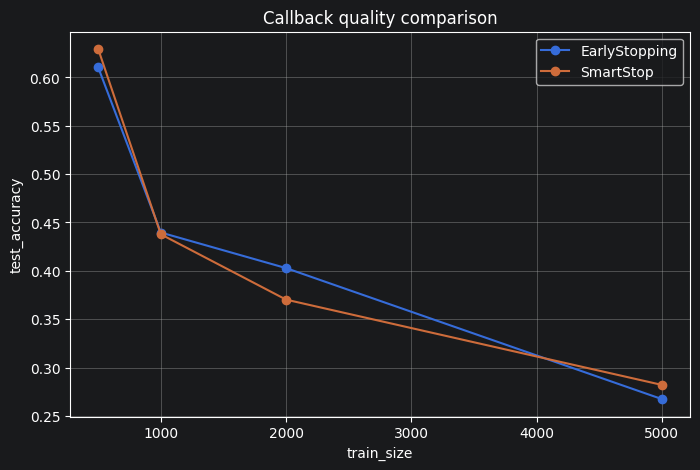

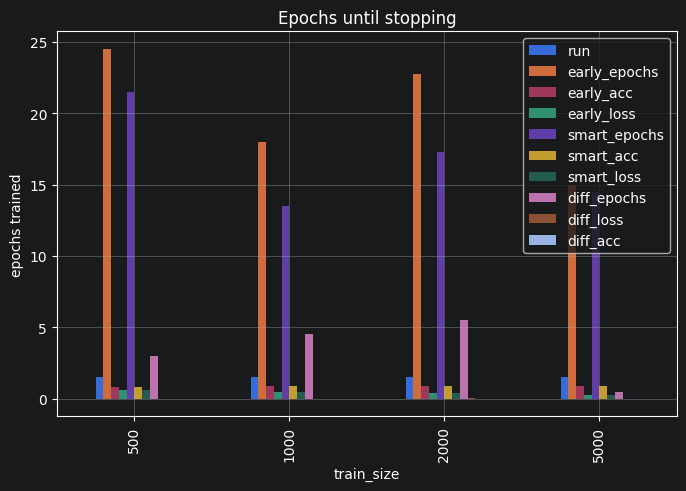

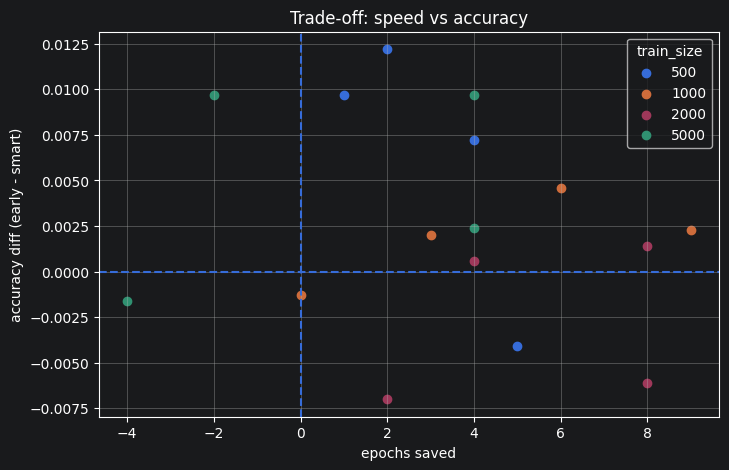

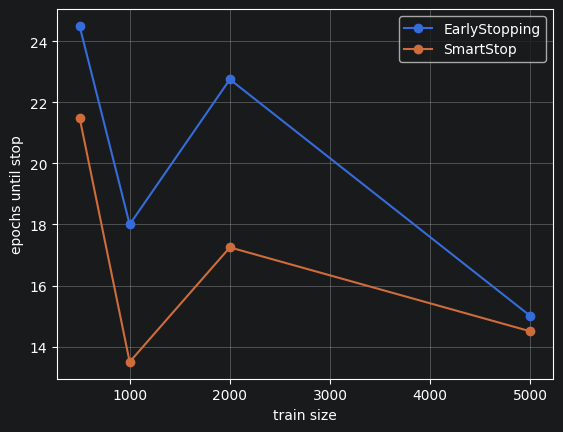

In [15]:
sizes = [500, 1000, 2000, 5000]
df = runner(sizes, X_train, y_train, X_test, y_test, build_mlp_overfit)
sum_df(df)

In [16]:
from pandas import read_csv, get_dummies
from sklearn.model_selection import train_test_split

df_student_med = read_csv('data/WineQT.csv')

X, Y = df_student_med[
    'fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol'.split(
        ',')
], df_student_med['quality']
X = get_dummies(X, drop_first=True)
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()
X = normalizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# print(y_test[:90])
def build_model_med():
    model = models.Sequential([
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


df_med = runner(sizes, X_train, y_train, X_test, y_test, build_model_med)

epoch=4 val_loss=1.3011 future=[np.float64(1.2501), np.float64(1.2168), np.float64(1.1937)] trend=-0.028170
epoch=5 val_loss=1.2930 future=[np.float64(1.2698), np.float64(1.2601), np.float64(1.2534)] trend=-0.008212
epoch=6 val_loss=1.2962 future=[np.float64(1.3134), np.float64(1.3138), np.float64(1.2974)] trend=-0.008039
epoch=7 val_loss=1.2825 future=[np.float64(1.2739), np.float64(1.2672), np.float64(1.2657)] trend=-0.004147
epoch=8 val_loss=1.2789 future=[np.float64(1.2747), np.float64(1.2728), np.float64(1.2687)] trend=-0.003012
epoch=9 val_loss=1.2746 future=[np.float64(1.2721), np.float64(1.2671), np.float64(1.2576)] trend=-0.007214
epoch=10 val_loss=1.2725 future=[np.float64(1.2683), np.float64(1.2613), np.float64(1.2556)] trend=-0.006355
epoch=11 val_loss=1.2762 future=[np.float64(1.2783), np.float64(1.2779), np.float64(1.2819)] trend=0.001777
epoch=12 val_loss=1.2696 future=[np.float64(1.2653), np.float64(1.2629), np.float64(1.2603)] trend=-0.002502
epoch=13 val_loss=1.2691 f

            early_acc  smart_acc  early_loss  smart_loss  early_epochs  \
train_size                                                               
500          0.548035   0.541485    1.076351    1.082554         29.50   
1000         0.526201   0.513100    1.063070    1.073881         30.75   
2000         0.498908   0.501092    1.069000    1.079550         27.75   
5000         0.517467   0.526201    1.062608    1.077978         29.00   

            smart_epochs  diff_epochs  diff_acc  diff_loss  
train_size                                                  
500                21.50          8.0  0.006550  -0.006203  
1000               18.75         12.0  0.013100  -0.010811  
2000               15.75         12.0 -0.002183  -0.010550  
5000               19.00         10.0 -0.008734  -0.015370  


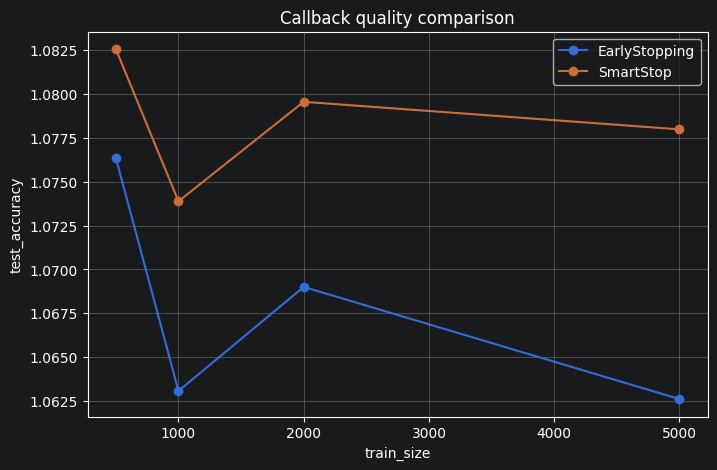

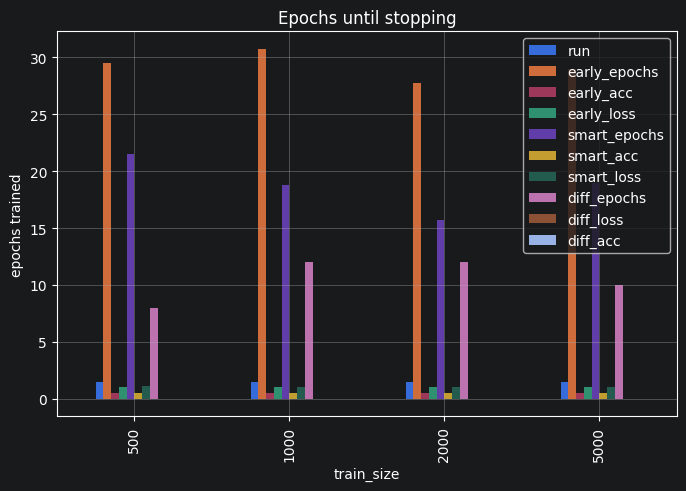

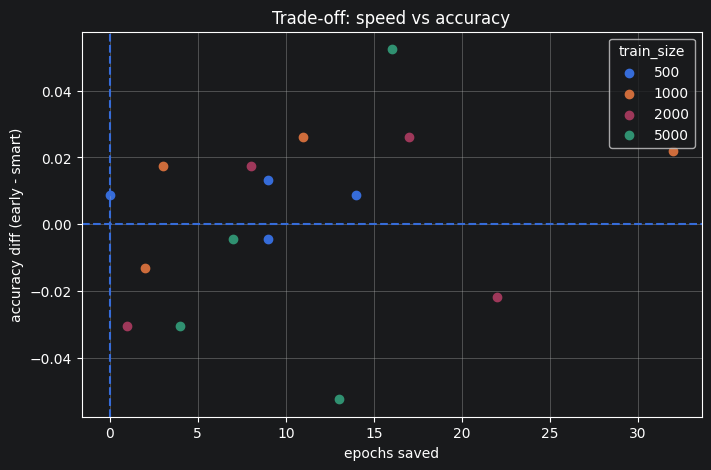

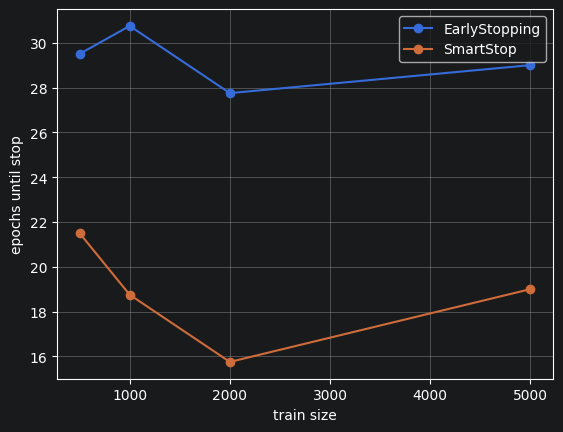

    train_size  run  early_epochs  early_acc  early_loss  smart_epochs  \
0          500    0            39   0.545852    1.069936            30   
1          500    1            27   0.554585    1.077182            18   
2          500    2            32   0.545852    1.073767            18   
3          500    3            20   0.545852    1.084518            20   
4         1000    0            26   0.537118    1.067733            23   
5         1000    1            53   0.545852    1.047781            21   
6         1000    2            24   0.497817    1.066705            13   
7         1000    3            20   0.524017    1.070061            18   
8         2000    0            13   0.441048    1.095671            12   
9         2000    1            35   0.528384    1.056023            13   
10        2000    2            27   0.502183    1.063985            19   
11        2000    3            36   0.524017    1.060319            19   
12        5000    0            30   0.

In [17]:
sum_df(df_med)
print(df_med.head(100))
